<a href="https://colab.research.google.com/github/raychelbright-coder/facial-emotion-recognition-cnn-resnet18/blob/main/CNN%26ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive

In [ ]:
# Mount Google Drive so the notebook can access datasets and save outputs.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install and Import Libraries

In [ ]:
# Import core libraries for image processing, model training, and evaluation.
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0


Load the Haar Cascade Face Detector

In [ ]:
# Load the Haar Cascade classifier used for detecting faces.
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

print("Haar Cascade face detector loaded successfully!")

Haar Cascade face detector loaded successfully!


Define Dataset Loading Function for CK+

In [ ]:
# Functions for loading and preprocessing CK+ images (grayscale, face detection, resize).
IMG_SIZE = 48
EMOTIONS = ['anger', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']

def load_images(folder_path):
    """
    Load and preprocess all images in a folder:
    - convert to grayscale
    - detect the face region
    - crop and resize to 48×48
    - normalise pixel values
    """
    images = []
    if not os.path.exists(folder_path):
        print(f"  WARNING: Folder not found: {folder_path}")
        return images

    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #convert to grays
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1,
                                               minNeighbors=5, minSize=(30, 30)) # detect face

        if len(faces) == 0:
            continue

        x, y, w, h = faces[0]
        face = gray[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face_resized = face_resized.reshape(IMG_SIZE, IMG_SIZE, 1)

        images.append(face_resized)

    return images

def load_dataset(train_path, test_path):
    """
    Loads the full dataset (training and testing) for all 6 emotion classes.
    Returns: X_train, y_train, X_test, y_test as NumPy arrays
    """
    X_train, y_train = [], []
    X_test,  y_test  = [], []

    for label, emotion in enumerate(EMOTIONS):
        print(f"  Loading class [{label}] {emotion}...")

        train_folder = os.path.join(train_path, emotion)
        train_imgs = load_images(train_folder)
        X_train.extend(train_imgs)
        y_train.extend([label] * len(train_imgs))

        test_folder = os.path.join(test_path, emotion)
        test_imgs = load_images(test_folder)
        X_test.extend(test_imgs)
        y_test.extend([label] * len(test_imgs))

        print(f"    Train: {len(train_imgs)} images | Test: {len(test_imgs)} images")

    X_train = np.array(X_train, dtype='float32')
    X_test  = np.array(X_test,  dtype='float32')
    y_train = np.array(y_train)
    y_test  = np.array(y_test)

    X_train = X_train / 255.0
    X_test  = X_test  / 255.0

    return X_train, y_train, X_test, y_test

print("Dataset loading functions defined!")

Dataset loading functions defined!


Load the CK+ Dataset

In [ ]:
# Load CK+ dataset into training and testing NumPy arrays.
CK_TRAIN_PATH = '/content/drive/MyDrive/CK+/train'
CK_TEST_PATH  = '/content/drive/MyDrive/CK+/test'

print("Loading CK+ dataset...")
X_train_ck, y_train_ck, X_test_ck, y_test_ck = load_dataset(CK_TRAIN_PATH, CK_TEST_PATH)

print(f"\nCK+ Dataset loaded:")
print(f"  X_train shape: {X_train_ck.shape}")
print(f"  y_train shape: {y_train_ck.shape}")
print(f"  X_test  shape: {X_test_ck.shape}")
print(f"  y_test  shape: {y_test_ck.shape}")
print(f"  Classes: {EMOTIONS}")

Loading CK+ dataset...
  Loading class [0] anger...
    Train: 31 images | Test: 14 images
  Loading class [1] fear...
    Train: 18 images | Test: 7 images
  Loading class [2] happiness...
    Train: 48 images | Test: 21 images
  Loading class [3] neutral...
    Train: 53 images | Test: 23 images
  Loading class [4] sadness...
    Train: 20 images | Test: 8 images
  Loading class [5] surprise...
    Train: 58 images | Test: 24 images

CK+ Dataset loaded:
  X_train shape: (228, 48, 48, 1)
  y_train shape: (228,)
  X_test  shape: (97, 48, 48, 1)
  y_test  shape: (97,)
  Classes: ['anger', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


Define the Custom CNN Model

In [ ]:
# Define the custom CNN architecture used for CK+ and JAFFE.
def build_custom_cnn(input_shape=(48, 48, 1), num_classes=6):
    """
    Builds the custom CNN architecture

    Architecture:
    - Conv2D (32 filters, 3x3, ReLU) + MaxPooling2D (2x2)
    - Conv2D (64 filters, 3x3, ReLU) + MaxPooling2D (2x2)
    - Conv2D (128 filters, 3x3, ReLU) + MaxPooling2D (2x2)
    - Flatten
    - Dense (128, ReLU) + Dropout (0.5)
    - Dense (6, Softmax) – output layer
    """
    model = Sequential([

        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,718 (1.36 MB)

 Trainable params: 355,718 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Compile and Train the Custom CNN on CK+

In [ ]:
# Compile and train the custom CNN on the CK+ dataset.
custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Custom CNN on CK+ dataset...")
history_cnn_ck = custom_cnn.fit(
    X_train_ck, y_train_ck,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_ck, y_test_ck),
    verbose=1
)

test_loss, test_acc = custom_cnn.evaluate(X_test_ck, y_test_ck, verbose=0)
print(f"\nCustom CNN – CK+ Test Accuracy: {test_acc * 100:.2f}%")

custom_cnn.save('/content/drive/MyDrive/custom_cnn_ck.h5')
print("Model saved to Google Drive as custom_cnn_ck.h5")

Training Custom CNN on CK+ dataset...
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.2018 - loss: 1.7429 - val_accuracy: 0.2474 - val_loss: 1.6920
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.2632 - loss: 1.7210 - val_accuracy: 0.2474 - val_loss: 1.7066
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.2675 - loss: 1.7201 - val_accuracy: 0.2474 - val_loss: 1.6803
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.2588 - loss: 1.7201 - val_accuracy: 0.4845 - val_loss: 1.6891
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.2632 - loss: 1.6841 - val_accuracy: 0.2474 - val_loss: 1.6560
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.3026 - loss: 1.6610 - val_accuracy: 0.2990 - val_loss: 1.6285
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.3640 - loss: 1.6774 - val_accuracy: 0.3711 - val_loss: 1.6337
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.3684 - loss: 1.5959 - 


Custom CNN – CK+ Test Accuracy: 76.29%
Model saved to Google Drive as custom_cnn_ck.h5


Plot Training & Validation Accuracy and Loss (CK+)

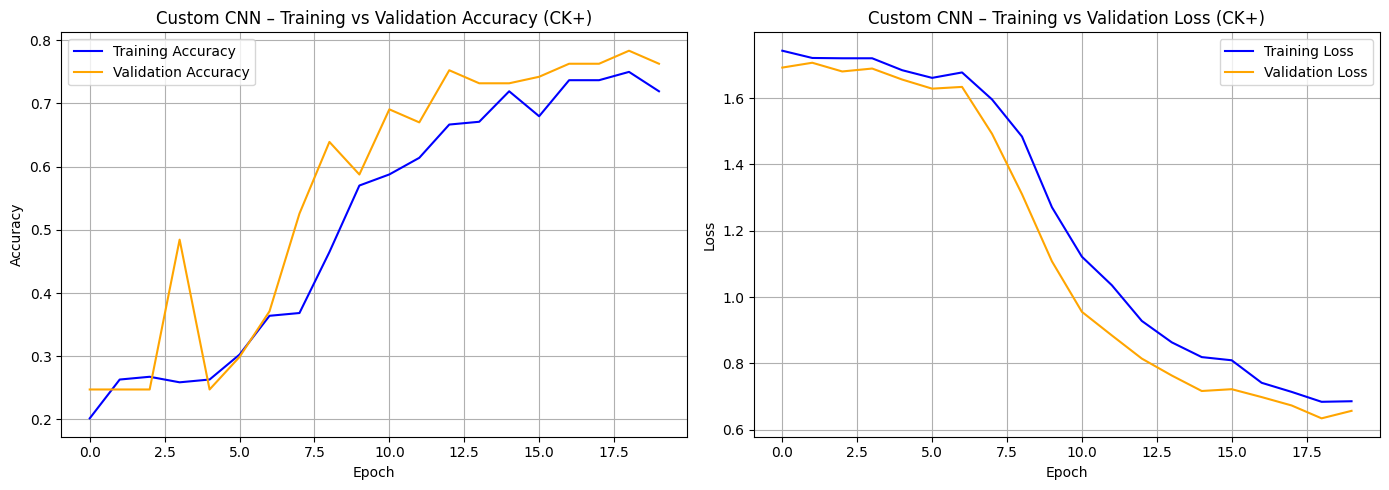

Plot saved to Google Drive.


In [ ]:
# Plot training and validation accuracy/loss for the CK+ model.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn_ck.history['accuracy'],     label='Training Accuracy',   color='blue')
ax1.plot(history_cnn_ck.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Custom CNN – Training vs Validation Accuracy (CK+)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_cnn_ck.history['loss'],     label='Training Loss',   color='blue')
ax2.plot(history_cnn_ck.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Custom CNN – Training vs Validation Loss (CK+)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_ck_accuracy_loss.png')
plt.show()
print("Plot saved to Google Drive.")

Confusion Matrix and Classification Report for Custom CNN on CK+

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


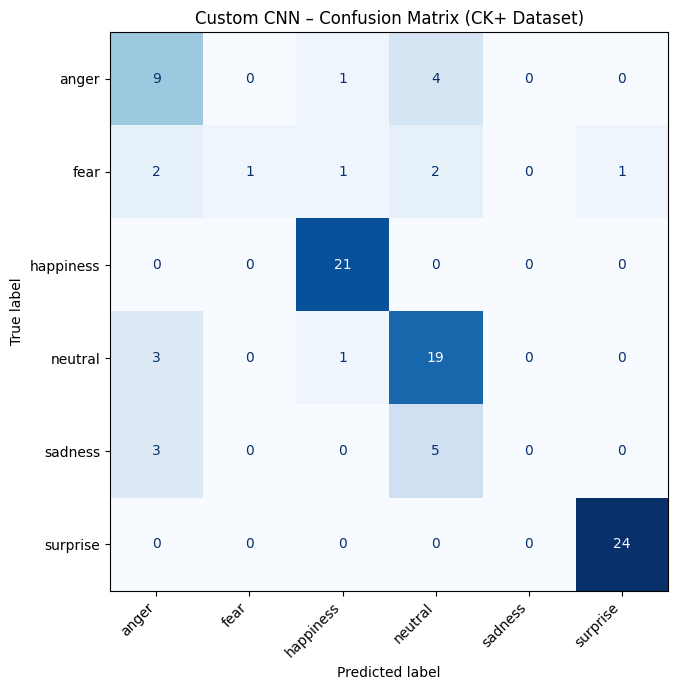


Classification Report – Custom CNN on CK+:
              precision    recall  f1-score   support

       anger       0.53      0.64      0.58        14
        fear       1.00      0.14      0.25         7
   happiness       0.88      1.00      0.93        21
     neutral       0.63      0.83      0.72        23
     sadness       0.00      0.00      0.00         8
    surprise       0.96      1.00      0.98        24

    accuracy                           0.76        97
   macro avg       0.67      0.60      0.58        97
weighted avg       0.73      0.76      0.72        97



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Generate confusion matrix and classification report for CK+ predictions.
y_pred_cnn_ck = np.argmax(custom_cnn.predict(X_test_ck), axis=1)

cm_cnn_ck = confusion_matrix(y_test_ck, y_pred_cnn_ck)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn_ck,
                               display_labels=EMOTIONS)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Custom CNN – Confusion Matrix (CK+ Dataset)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_ck_confusion_matrix.png')
plt.show()

print("\nClassification Report – Custom CNN on CK+:")
print(classification_report(y_test_ck, y_pred_cnn_ck, target_names=EMOTIONS))

Load JAFFE-[70,30] Dataset (Second Dataset)

In [ ]:
# Load and preprocess the JAFFE dataset using the same pipeline as CK+.
import random
from sklearn.model_selection import train_test_split

JAFFE_PATH = '/content/drive/MyDrive/JAFFE-[70,30]'

JAFFE_EMOTIONS = ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

def load_jaffe_dataset(root_path, emotion_list):
    """
    Loads JAFFE dataset from a structure like:
    root_path/train/EmotionLabel/image.tiff
    root_path/test/EmotionLabel/image.tiff

    Applies same preprocessing as CK+ by reusing the 'load_images' function:
    - Haar Cascade face detection
    - Greyscale, crop, resize to 48x48
    - Normalise to [0,1]
    """
    X_train, y_train = [], []
    X_test,  y_test  = [], []

    train_base_path = os.path.join(root_path, 'train')
    test_base_path  = os.path.join(root_path, 'test')

    if not os.path.exists(train_base_path):
        print(f"ERROR: JAFFE train folder not found at {train_base_path}")
        return None, None, None, None
    if not os.path.exists(test_base_path):
        print(f"ERROR: JAFFE test folder not found at {test_base_path}")
        return None, None, None, None

    print("Loading JAFFE train data...")
    for label, emotion in enumerate(emotion_list):
        print(f"  Loading class [{label}] {emotion} from train...")
        emotion_folder = os.path.join(train_base_path, emotion)
        train_imgs = load_images(emotion_folder)
        X_train.extend(train_imgs)
        y_train.extend([label] * len(train_imgs))
        print(f"    Loaded {len(train_imgs)} images for {emotion}")


    print("Loading JAFFE test data...")
    for label, emotion in enumerate(emotion_list):
        print(f"  Loading class [{label}] {emotion} from test...")
        emotion_folder = os.path.join(test_base_path, emotion)
        test_imgs = load_images(emotion_folder)
        X_test.extend(test_imgs)
        y_test.extend([label] * len(test_imgs))
        print(f"    Loaded {len(test_imgs)} images for {emotion}")

    X_train = np.array(X_train, dtype='float32')
    X_test  = np.array(X_test,  dtype='float32')
    y_train = np.array(y_train)
    y_test  = np.array(y_test)

    X_train = X_train / 255.0
    X_test  = X_test  / 255.0

    return X_train, y_train, X_test, y_test

print("Loading JAFFE dataset...")
X_train_jaffe, y_train_jaffe, X_test_jaffe, y_test_jaffe = load_jaffe_dataset(JAFFE_PATH, JAFFE_EMOTIONS)

if X_train_jaffe is not None and X_train_jaffe.size > 0:
    print(f"\nJAFFE Dataset loaded:")
    print(f"  X_train shape: {X_train_jaffe.shape}")
    print(f"  y_train shape: {y_train_jaffe.shape}")
    print(f"  X_test  shape: {X_test_jaffe.shape}")
    print(f"  y_test  shape: {y_test_jaffe.shape}")
    print(f"  Classes: {JAFFE_EMOTIONS}")
else:
    print("\nWARNING: No JAFFE images were loaded. Check paths and file contents and ensure subfolders exist.")

Loading JAFFE dataset...
Loading JAFFE train data...
  Loading class [0] Angry from train...
    Loaded 20 images for Angry
  Loading class [1] Fear from train...
    Loaded 22 images for Fear
  Loading class [2] Happy from train...
    Loaded 22 images for Happy
  Loading class [3] Neutral from train...
    Loaded 21 images for Neutral
  Loading class [4] Sad from train...
    Loaded 22 images for Sad
  Loading class [5] Surprise from train...
    Loaded 21 images for Surprise
Loading JAFFE test data...
  Loading class [0] Angry from test...
    Loaded 9 images for Angry
  Loading class [1] Fear from test...
    Loaded 10 images for Fear
  Loading class [2] Happy from test...
    Loaded 9 images for Happy
  Loading class [3] Neutral from test...
    Loaded 9 images for Neutral
  Loading class [4] Sad from test...
    Loaded 9 images for Sad
  Loading class [5] Surprise from test...
    Loaded 9 images for Surprise

JAFFE Dataset loaded:
  X_train shape: (128, 48, 48, 1)
  y_train shap

In [ ]:
import os
jaffe_train_path = '/content/drive/MyDrive/JAFFE-[70,30]/train'
jaffe_test_path = '/content/drive/MyDrive/JAFFE-[70,30]/test'

print(f"Contents of {jaffe_train_path}:")
if os.path.exists(jaffe_train_path):
    for item in os.listdir(jaffe_train_path):
        print(item)
else:
    print("Train directory not found.")

print(f"\nContents of {jaffe_test_path}:")
if os.path.exists(jaffe_test_path):
    for item in os.listdir(jaffe_test_path):
        print(item)
else:
    print("Test directory not found.")

Contents of /content/drive/MyDrive/JAFFE-[70,30]/train:
Angry
Fear
Neutral
Happy
Sad
Surprise

Contents of /content/drive/MyDrive/JAFFE-[70,30]/test:
Angry
Neutral
Happy
Fear
Surprise
Sad


In [ ]:
import os

jaffe_path = '/content/drive/MyDrive/JAFFE-[70,30]'

if os.path.exists(jaffe_path):
    print(f"Contents of {jaffe_path}:")
    for item in os.listdir(jaffe_path):
        print(item)
else:
    print(f"The path {jaffe_path} does not exist.")

Contents of /content/drive/MyDrive/JAFFE-[70,30]:
test
train


Train Custom CNN on JAFFE and Evaluate

In [ ]:
# Train and evaluate the custom CNN on the JAFFE dataset.
custom_cnn_jaffe = build_custom_cnn()
custom_cnn_jaffe.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Custom CNN on JAFFE dataset...")
history_cnn_jaffe = custom_cnn_jaffe.fit(
    X_train_jaffe, y_train_jaffe,
    epochs=20,
    batch_size=16,
    validation_data=(X_test_jaffe, y_test_jaffe),
    verbose=1
)

test_loss_jaffe, test_acc_jaffe = custom_cnn_jaffe.evaluate(
    X_test_jaffe, y_test_jaffe, verbose=0
)
print(f"\nCustom CNN – JAFFE Test Accuracy: {test_acc_jaffe * 100:.2f}%")

custom_cnn_jaffe.save('/content/drive/MyDrive/custom_cnn_jaffe.h5')
print("Model saved to Google Drive as custom_cnn_jaffe.h5")

Training Custom CNN on JAFFE dataset...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.1094 - loss: 1.8284 - val_accuracy: 0.1636 - val_loss: 1.7933
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1797 - loss: 1.7895 - val_accuracy: 0.1636 - val_loss: 1.7941
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.1484 - loss: 1.8026 - val_accuracy: 0.1636 - val_loss: 1.7921
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2031 - loss: 1.7897 - val_accuracy: 0.1636 - val_loss: 1.7911
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.1953 - loss: 1.7901 - val_accuracy: 0.1636 - val_loss: 1.7906
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.2344 - loss: 1.7774 - val_accuracy: 0.1636 - val_loss: 1.7911
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.1953 - loss: 1.7953 - val_accuracy: 0.1636 - val_loss: 1.7897
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.1953 - loss: 1.7920 - val_accuracy: 0.2182 - val_loss: 1.7874
Epoch 9/20


Custom CNN – JAFFE Test Accuracy: 60.00%
Model saved to Google Drive as custom_cnn_jaffe.h5


JAFFE Plots + Confusion Matrix

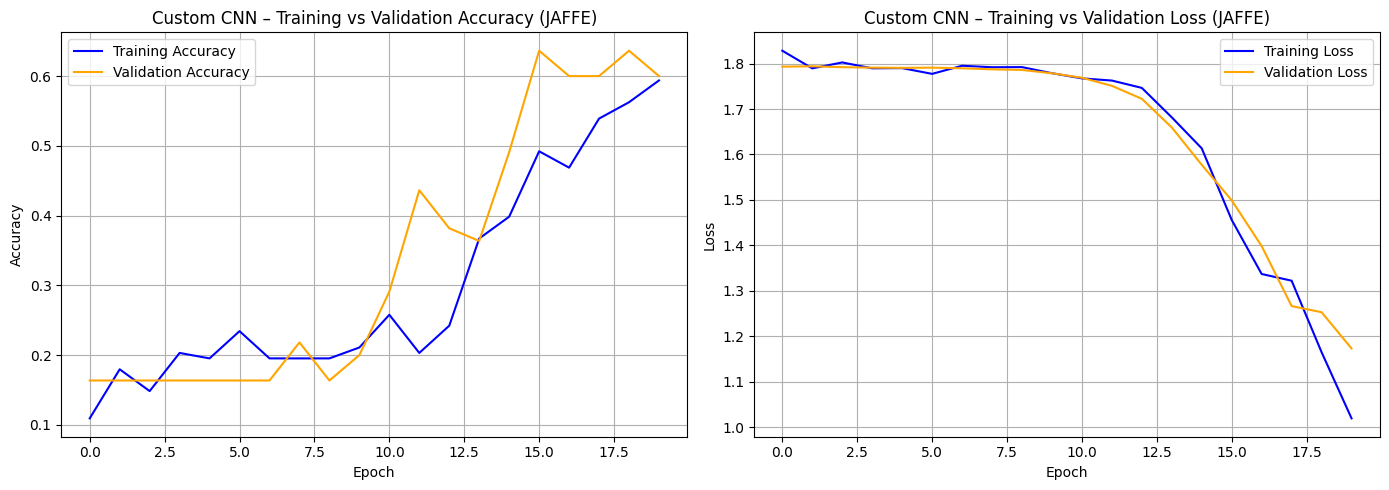

In [ ]:
# Accuracy and Loss plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cnn_jaffe.history['accuracy'],     label='Training Accuracy',   color='blue')
ax1.plot(history_cnn_jaffe.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Custom CNN – Training vs Validation Accuracy (JAFFE)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_cnn_jaffe.history['loss'],     label='Training Loss',   color='blue')
ax2.plot(history_cnn_jaffe.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Custom CNN – Training vs Validation Loss (JAFFE)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_jaffe_accuracy_loss.png')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


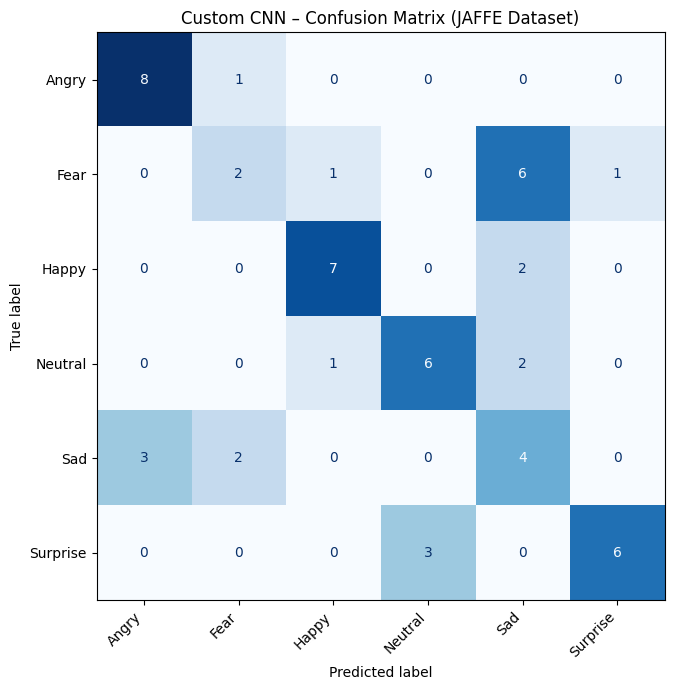


Classification Report – Custom CNN on JAFFE:
              precision    recall  f1-score   support

       Angry       0.73      0.89      0.80         9
        Fear       0.40      0.20      0.27        10
       Happy       0.78      0.78      0.78         9
     Neutral       0.67      0.67      0.67         9
         Sad       0.29      0.44      0.35         9
    Surprise       0.86      0.67      0.75         9

    accuracy                           0.60        55
   macro avg       0.62      0.61      0.60        55
weighted avg       0.62      0.60      0.60        55



In [ ]:
# Confusion matrix and Classification report
y_pred_cnn_jaffe = np.argmax(custom_cnn_jaffe.predict(X_test_jaffe), axis=1)
cm_cnn_jaffe = confusion_matrix(y_test_jaffe, y_pred_cnn_jaffe)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn_jaffe,
                               display_labels=JAFFE_EMOTIONS)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Custom CNN – Confusion Matrix (JAFFE Dataset)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_jaffe_confusion_matrix.png')
plt.show()

print("\nClassification Report – Custom CNN on JAFFE:")
print(classification_report(y_test_jaffe, y_pred_cnn_jaffe,
                             target_names=JAFFE_EMOTIONS))

Install PyTorch Libraries for ResNet18

In [ ]:
# Install and import PyTorch libraries for ResNet18 transfer learning.
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', '--quiet'])

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
GPU available: False
Using device: cpu


Define Haar Cascade Face Detection Function for PyTorch Models

In [ ]:
def detect_face_224(image_path):
    """
    Detects a face in an image and returns it resized to 224x224 pixels.
    Used for ResNet18 and EfficientNetB0 (both require 224x224 input).

    From Lab 16:
    - Converts to greyscale using cv2.COLOR_BGR2GRAY
    - detectMultiScale: scaleFactor=1.1, minNeighbors=5, minSize=(30,30)
    - Crops first detected face, resizes to 224x224
    - Returns None if no face detected
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1,
                                           minNeighbors=5, minSize=(30, 30))
    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]
    face = img[y:y+h, x:x+w]
    face_resized = cv2.resize(face, (224, 224))
    return face_resized

print("Face detection function (224x224) defined!")

Face detection function (224x224) defined!


PyTorch Transforms & Dataset Loading

In [ ]:
# Define transforms and load CK+ and JAFFE datasets for PyTorch.
from torch.utils.data import Dataset
from PIL import Image
import os
import cv2
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

CK_TRAIN_PATH_PT = '/content/drive/MyDrive/CK+/train'
CK_TEST_PATH_PT  = '/content/drive/MyDrive/CK+/test'

train_dataset_ck = datasets.ImageFolder(root=CK_TRAIN_PATH_PT, transform=transform)
test_dataset_ck  = datasets.ImageFolder(root=CK_TEST_PATH_PT,  transform=transform)

train_loader_ck = DataLoader(train_dataset_ck, batch_size=32, shuffle=True,  num_workers=0)
test_loader_ck  = DataLoader(test_dataset_ck,  batch_size=32, shuffle=False, num_workers=0)

print(f"CK+ (PyTorch): {len(train_dataset_ck)} train | {len(test_dataset_ck)} test")
print(f"Classes: {train_dataset_ck.classes}")

# Custom PyTorch dataset class for JAFFE with face detection.
class JAFFEDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.data = []
        print(f"JAFFEDataset: Initializing with root_dir: {root_dir}")
        self.classes = sorted([d.name for d in os.scandir(root_dir) if d.is_dir()])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        print(f"JAFFEDataset: Found classes (subdirectories): {self.classes}")

        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            print(f"JAFFEDataset: Processing class_path: {class_path}")
            if not os.path.exists(class_path):
                print(f"JAFFEDataset: WARNING: Class path does not exist: {class_path}")
                continue
            for img_file in os.listdir(class_path):
                img_path = os.path.join(class_path, img_file)
                if os.path.isfile(img_path) and img_file.lower().endswith(('.tiff', '.tif', '.jpg', '.png')):
                    self.data.append((img_path, self.class_to_idx[class_name]))
        print(f"JAFFEDataset: Total images loaded into self.data: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        face_img_bgr = detect_face_224(img_path)

        if face_img_bgr is None:
            img_rgb = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img_rgb = cv2.cvtColor(face_img_bgr, cv2.COLOR_BGR2RGB)

        pil_img = Image.fromarray(img_rgb)
        if self.transform:
            pil_img = self.transform(pil_img)

        return pil_img, label

JAFFE_ROOT_PATH_PT = '/content/drive/MyDrive/JAFFE-[70,30]'
JAFFE_TRAIN_PATH_PT_PYTORCH = os.path.join(JAFFE_ROOT_PATH_PT, 'train')
JAFFE_TEST_PATH_PT_PYTORCH  = os.path.join(JAFFE_ROOT_PATH_PT, 'test')

train_dataset_jaffe = JAFFEDataset(JAFFE_TRAIN_PATH_PT_PYTORCH, transform=transform)
test_dataset_jaffe  = JAFFEDataset(JAFFE_TEST_PATH_PT_PYTORCH,  transform=transform)

train_loader_jaffe = DataLoader(train_dataset_jaffe, batch_size=8,  shuffle=True,  num_workers=0)
test_loader_jaffe  = DataLoader(test_dataset_jaffe,  batch_size=8,  shuffle=False, num_workers=0)

print(f"\nJAFFE (PyTorch): {len(train_dataset_jaffe)} train | {len(test_dataset_jaffe)} test")

CK+ (PyTorch): 228 train | 97 test
Classes: ['anger', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
JAFFEDataset: Initializing with root_dir: /content/drive/MyDrive/JAFFE-[70,30]/train
JAFFEDataset: Found classes (subdirectories): ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
JAFFEDataset: Processing class_path: /content/drive/MyDrive/JAFFE-[70,30]/train/Angry
JAFFEDataset: Processing class_path: /content/drive/MyDrive/JAFFE-[70,30]/train/Fear
JAFFEDataset: Processing class_path: /content/drive/MyDrive/JAFFE-[70,30]/train/Happy
JAFFEDataset: Processing class_path: /content/drive/MyDrive/JAFFE-[70,30]/train/Neutral
JAFFEDataset: Processing class_path: /content/drive/MyDrive/JAFFE-[70,30]/train/Sad
JAFFEDataset: Processing class_path: /content/drive/MyDrive/JAFFE-[70,30]/train/Surprise
JAFFEDataset: Total images loaded into self.data: 128
JAFFEDataset: Initializing with root_dir: /content/drive/MyDrive/JAFFE-[70,30]/test
JAFFEDataset: Found classes (subdirectories): [

In [ ]:
import os

ck_dataset_path = '/content/drive/MyDrive/CK_dataset'

print(f"Contents of {ck_dataset_path}:")
if os.path.exists(ck_dataset_path):
    for item in os.listdir(ck_dataset_path):
        print(item)
else:
    print(f"The path {ck_dataset_path} does not exist.")

Contents of /content/drive/MyDrive/CK_dataset:
train
test


Build ResNet18 Transfer Learning Model

In [ ]:
# Load ResNet18 and replace the final layer for 6‑class emotion classification.
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 6) # 6 emotion classes

# Move model to GPU/CPU
resnet18 = resnet18.to(device)

# Loss function: CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Adam optimiser with lr=0.0001
optimizer_resnet = optim.Adam(resnet18.parameters(), lr=0.0001)

print("ResNet18 model built and ready to train.")
print(f"  Final layer: Linear({num_features}, 6)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


ResNet18 model built and ready to train.
  Final layer: Linear(512, 6)


Training Loop for ResNet18 on CK+

In [ ]:
# Train ResNet18 on CK+ using a standard fine‑tuning loop.
NUM_EPOCHS_RESNET = 25

train_acc_history_rn = []
test_acc_history_rn  = []
train_loss_history_rn = []
test_loss_history_rn  = []

print(f"Training ResNet18 on CK+ for {NUM_EPOCHS_RESNET} epochs...")

for epoch in range(NUM_EPOCHS_RESNET):

    resnet18.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_ck:
        images = images.to(device)
        labels = labels.to(device)
        optimizer_resnet.zero_grad()

        outputs = resnet18(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader_ck)

    resnet18.eval()
    test_correct = 0
    test_total   = 0
    test_running_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader_ck:
            images = images.to(device)
            labels = labels.to(device)
            outputs = resnet18(images)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            test_total   += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc  = 100 * test_correct / test_total
    test_loss = test_running_loss / len(test_loader_ck)

    train_acc_history_rn.append(train_acc)
    test_acc_history_rn.append(test_acc)
    train_loss_history_rn.append(train_loss)
    test_loss_history_rn.append(test_loss)

    print(f"  Epoch [{epoch+1:2d}/{NUM_EPOCHS_RESNET}]  "
          f"Train Acc: {train_acc:.2f}%  Loss: {train_loss:.4f}  |  "
          f"Test Acc: {test_acc:.2f}%  Loss: {test_loss:.4f}")

torch.save(resnet18.state_dict(), '/content/drive/MyDrive/resnet18_ck.pth')
print(f"\nResNet18 saved to Google Drive.")
print(f"Final Test Accuracy on CK+: {test_acc_history_rn[-1]:.2f}%")

Training ResNet18 on CK+ for 25 epochs...
  Epoch [ 1/25]  Train Acc: 34.21%  Loss: 1.5603  |  Test Acc: 53.61%  Loss: 1.2629
  Epoch [ 2/25]  Train Acc: 82.46%  Loss: 0.7040  |  Test Acc: 65.98%  Loss: 0.7095
  Epoch [ 3/25]  Train Acc: 89.04%  Loss: 0.4497  |  Test Acc: 68.04%  Loss: 0.6452
  Epoch [ 4/25]  Train Acc: 95.18%  Loss: 0.2834  |  Test Acc: 71.13%  Loss: 0.6213
  Epoch [ 5/25]  Train Acc: 97.37%  Loss: 0.3717  |  Test Acc: 65.98%  Loss: 0.6278
  Epoch [ 6/25]  Train Acc: 100.00%  Loss: 0.1094  |  Test Acc: 69.07%  Loss: 0.6402
  Epoch [ 7/25]  Train Acc: 100.00%  Loss: 0.0824  |  Test Acc: 70.10%  Loss: 0.6390
  Epoch [ 8/25]  Train Acc: 99.56%  Loss: 0.1622  |  Test Acc: 71.13%  Loss: 0.6880
  Epoch [ 9/25]  Train Acc: 97.81%  Loss: 0.3676  |  Test Acc: 71.13%  Loss: 0.6420
  Epoch [10/25]  Train Acc: 98.68%  Loss: 0.1134  |  Test Acc: 73.20%  Loss: 0.6718
  Epoch [11/25]  Train Acc: 99.56%  Loss: 0.0729  |  Test Acc: 71.13%  Loss: 0.6992
  Epoch [12/25]  Train Acc: 98.6

Plot ResNet18 Training Graphs (CK+)

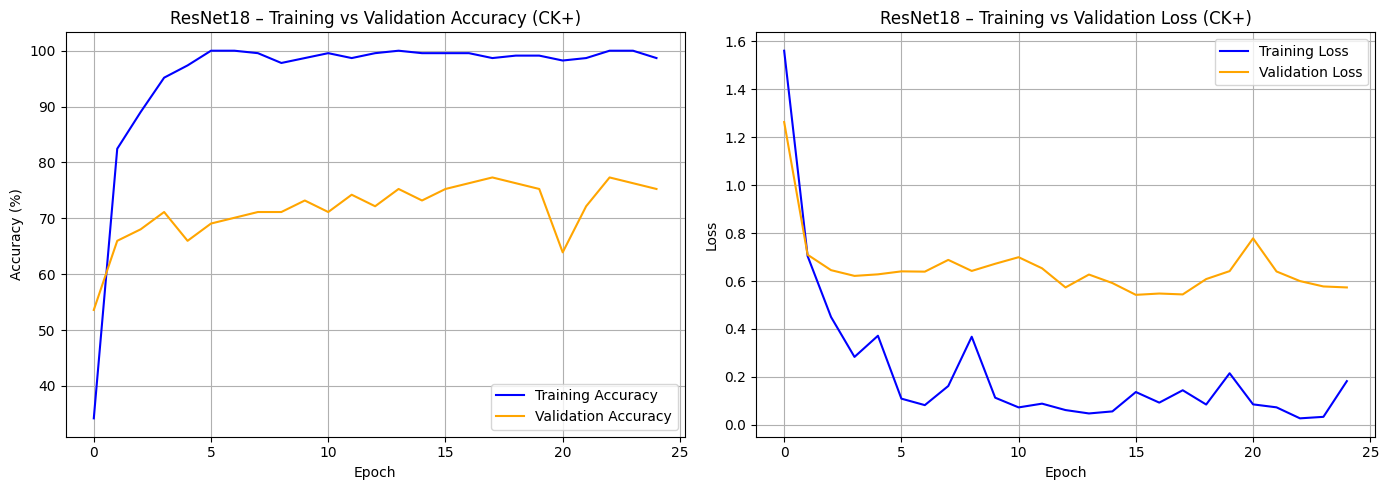

ResNet18 training plot saved.


In [ ]:
# Plot accuracy and loss curves for ResNet18 on CK+.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_acc_history_rn, label='Training Accuracy',   color='blue')
ax1.plot(test_acc_history_rn,  label='Validation Accuracy', color='orange')
ax1.set_title('ResNet18 – Training vs Validation Accuracy (CK+)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.legend(); ax1.grid(True)

ax2.plot(train_loss_history_rn, label='Training Loss',   color='blue')
ax2.plot(test_loss_history_rn,  label='Validation Loss', color='orange')
ax2.set_title('ResNet18 – Training vs Validation Loss (CK+)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resnet18_ck_accuracy_loss.png')
plt.show()
print("ResNet18 training plot saved.")

Confusion Matrix for ResNet18 on CK+

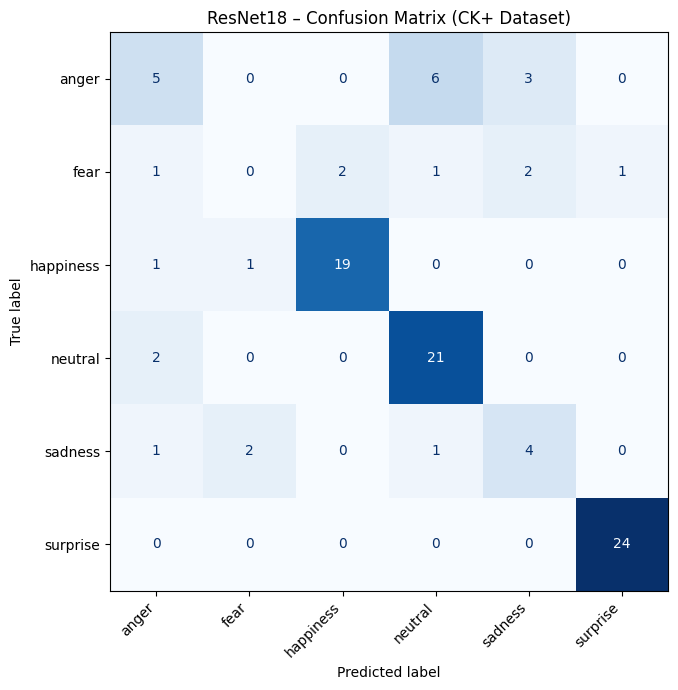


Classification Report – ResNet18 on CK+:
              precision    recall  f1-score   support

       anger       0.50      0.36      0.42        14
        fear       0.00      0.00      0.00         7
   happiness       0.90      0.90      0.90        21
     neutral       0.72      0.91      0.81        23
     sadness       0.44      0.50      0.47         8
    surprise       0.96      1.00      0.98        24

    accuracy                           0.75        97
   macro avg       0.59      0.61      0.60        97
weighted avg       0.71      0.75      0.73        97



In [ ]:
# Generate confusion matrix and classification report for ResNet18 on CK+.
all_preds_rn_ck  = []
all_labels_rn_ck = []

resnet18.eval()
with torch.no_grad():
    for images, labels in test_loader_ck:
        images = images.to(device)
        outputs = resnet18(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_rn_ck.extend(predicted.cpu().numpy())
        all_labels_rn_ck.extend(labels.numpy())

cm_rn_ck = confusion_matrix(all_labels_rn_ck, all_preds_rn_ck)
class_names_ck = train_dataset_ck.classes

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rn_ck,
                               display_labels=class_names_ck)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('ResNet18 – Confusion Matrix (CK+ Dataset)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resnet18_ck_confusion_matrix.png')
plt.show()

print("\nClassification Report – ResNet18 on CK+:")
print(classification_report(all_labels_rn_ck, all_preds_rn_ck,
                             target_names=class_names_ck))

Train and Evaluate ResNet18 on JAFFE

Training ResNet18 on JAFFE for 20 epochs...
  Epoch [ 1/20]  Train: 39.06%  |  Test: 34.55%
  Epoch [ 2/20]  Train: 90.62%  |  Test: 50.91%
  Epoch [ 3/20]  Train: 99.22%  |  Test: 58.18%
  Epoch [ 4/20]  Train: 100.00%  |  Test: 76.36%
  Epoch [ 5/20]  Train: 100.00%  |  Test: 76.36%
  Epoch [ 6/20]  Train: 100.00%  |  Test: 78.18%
  Epoch [ 7/20]  Train: 100.00%  |  Test: 63.64%
  Epoch [ 8/20]  Train: 100.00%  |  Test: 69.09%
  Epoch [ 9/20]  Train: 100.00%  |  Test: 72.73%
  Epoch [10/20]  Train: 100.00%  |  Test: 70.91%
  Epoch [11/20]  Train: 100.00%  |  Test: 67.27%
  Epoch [12/20]  Train: 99.22%  |  Test: 78.18%
  Epoch [13/20]  Train: 99.22%  |  Test: 70.91%
  Epoch [14/20]  Train: 100.00%  |  Test: 61.82%
  Epoch [15/20]  Train: 100.00%  |  Test: 70.91%
  Epoch [16/20]  Train: 100.00%  |  Test: 70.91%
  Epoch [17/20]  Train: 100.00%  |  Test: 74.55%
  Epoch [18/20]  Train: 100.00%  |  Test: 78.18%
  Epoch [19/20]  Train: 100.00%  |  Test: 76.36%
  Epoch [20/20]  Train: 96.88%

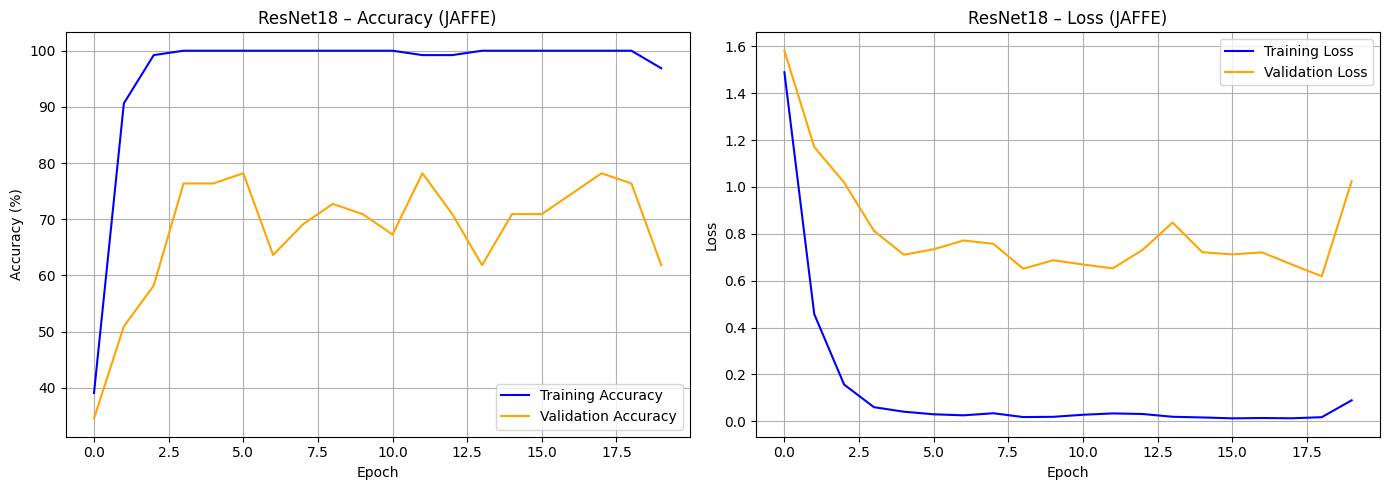

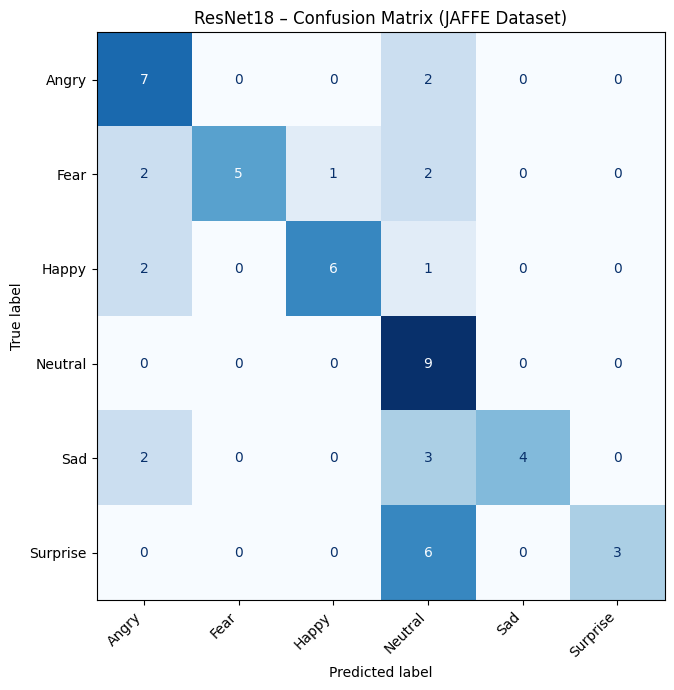


Classification Report – ResNet18 on JAFFE:
              precision    recall  f1-score   support

       Angry       0.54      0.78      0.64         9
        Fear       1.00      0.50      0.67        10
       Happy       0.86      0.67      0.75         9
     Neutral       0.39      1.00      0.56         9
         Sad       1.00      0.44      0.62         9
    Surprise       1.00      0.33      0.50         9

    accuracy                           0.62        55
   macro avg       0.80      0.62      0.62        55
weighted avg       0.80      0.62      0.62        55



In [ ]:
# Fine‑tune ResNet18 on the JAFFE dataset.
resnet18_jaffe = models.resnet18(pretrained=True)
resnet18_jaffe.fc = nn.Linear(resnet18_jaffe.fc.in_features, 6)
resnet18_jaffe = resnet18_jaffe.to(device)

optimizer_resnet_jaffe = optim.Adam(resnet18_jaffe.parameters(), lr=0.0001)

NUM_EPOCHS_JAFFE = 20  # fewer epochs – JAFFE is very small, risk of overfitting

train_acc_history_jaffe = []
test_acc_history_jaffe  = []
train_loss_history_jaffe = []
test_loss_history_jaffe  = []

print(f"Training ResNet18 on JAFFE for {NUM_EPOCHS_JAFFE} epochs...")

for epoch in range(NUM_EPOCHS_JAFFE):

    resnet18_jaffe.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_jaffe:
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet_jaffe.zero_grad()
        outputs = resnet18_jaffe(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet_jaffe.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader_jaffe)

    resnet18_jaffe.eval()
    test_correct = 0
    test_total   = 0
    test_running_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader_jaffe:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet18_jaffe(images)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            test_total   += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_acc  = 100 * test_correct / test_total
    test_loss = test_running_loss / len(test_loader_jaffe)

    train_acc_history_jaffe.append(train_acc)
    test_acc_history_jaffe.append(test_acc)
    train_loss_history_jaffe.append(train_loss)
    test_loss_history_jaffe.append(test_loss)

    print(f"  Epoch [{epoch+1:2d}/{NUM_EPOCHS_JAFFE}]  "
          f"Train: {train_acc:.2f}%  |  Test: {test_acc:.2f}%")

torch.save(resnet18_jaffe.state_dict(), '/content/drive/MyDrive/resnet18_jaffe.pth')
print(f"\nResNet18 JAFFE saved. Final Test Accuracy: {test_acc_history_jaffe[-1]:.2f}%")

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_acc_history_jaffe, label='Training Accuracy',   color='blue')
ax1.plot(test_acc_history_jaffe,  label='Validation Accuracy', color='orange')
ax1.set_title('ResNet18 – Accuracy (JAFFE)'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(True)
ax2.plot(train_loss_history_jaffe, label='Training Loss',   color='blue')
ax2.plot(test_loss_history_jaffe,  label='Validation Loss', color='orange')
ax2.set_title('ResNet18 – Loss (JAFFE)'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resnet18_jaffe_accuracy_loss.png')
plt.show()

# Confusion matrix
all_preds_jaffe  = []
all_labels_jaffe = []
resnet18_jaffe.eval()
with torch.no_grad():
    for images, labels in test_loader_jaffe:
        images = images.to(device)
        outputs = resnet18_jaffe(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_jaffe.extend(predicted.cpu().numpy())
        all_labels_jaffe.extend(labels.numpy())

cm_rn_jaffe = confusion_matrix(all_labels_jaffe, all_preds_jaffe)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rn_jaffe,
                               display_labels=JAFFE_EMOTIONS)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('ResNet18 – Confusion Matrix (JAFFE Dataset)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resnet18_jaffe_confusion_matrix.png')
plt.show()

print("\nClassification Report – ResNet18 on JAFFE:")
print(classification_report(all_labels_jaffe, all_preds_jaffe,
                             target_names=JAFFE_EMOTIONS))

In [ ]:
print(f"Number of epochs in train_acc_history_jaffe: {len(train_acc_history_jaffe)}")
print(f"Number of epochs in test_acc_history_jaffe: {len(test_acc_history_jaffe)}")

print("\nLast 5 training accuracies:")
print(train_acc_history_jaffe[-5:])

print("\nLast 5 validation accuracies:")
print(test_acc_history_jaffe[-5:])

Number of epochs in train_acc_history_jaffe: 20
Number of epochs in test_acc_history_jaffe: 20

Last 5 training accuracies:
[100.0, 100.0, 100.0, 100.0, 96.875]

Last 5 validation accuracies:
[70.9090909090909, 74.54545454545455, 78.18181818181819, 76.36363636363636, 61.81818181818182]


Cross-Dataset Results Summary

In [ ]:
# Summarise and compare model performance across CK+ and JAFFE datasets.
cnn_ck_acc    = max(history_cnn_ck.history['val_accuracy'])    * 100
cnn_jaffe_acc = max(history_cnn_jaffe.history['val_accuracy']) * 100
rn_ck_acc     = max(test_acc_history_rn)
rn_jaffe_acc  = max(test_acc_history_jaffe)

print("=" * 60)
print("  CROSS-DATASET RESULTS SUMMARY")
print("=" * 60)
print(f"  {'Model':<32} {'CK+ Acc':>10} {'JAFFE Acc':>10}")
print("-" * 60)
print(f"  {'Custom CNN':<32} {cnn_ck_acc:>9.2f}% {cnn_jaffe_acc:>9.2f}%")
print(f"  {'ResNet18 (Transfer Learning)':<32} {rn_ck_acc:>9.2f}% {rn_jaffe_acc:>9.2f}%")
print("=" * 60)

# Comparison with Assignment 1 HOG-SVM baseline
print()
print("  COMPARISON WITH ASSIGNMENT 1 (HOG-SVM baseline on CK+):")
print(f"  HOG-SVM (Assignment 1, CK+):  62.50%")
print(f"  Custom CNN (Assignment 2):     {cnn_ck_acc:.2f}%  (+{cnn_ck_acc-62.5:.2f} pp)")
print(f"  ResNet18   (Assignment 2):     {rn_ck_acc:.2f}%  (+{rn_ck_acc-62.5:.2f} pp)")
print("=" * 60)

  CROSS-DATASET RESULTS SUMMARY
  Model                               CK+ Acc  JAFFE Acc
------------------------------------------------------------
  Custom CNN                           78.35%     63.64%
  ResNet18 (Transfer Learning)         77.32%     78.18%

  COMPARISON WITH ASSIGNMENT 1 (HOG-SVM baseline on CK+):
  HOG-SVM (Assignment 1, CK+):  62.50%
  Custom CNN (Assignment 2):     78.35%  (+15.85 pp)
  ResNet18   (Assignment 2):     77.32%  (+14.82 pp)


Single Image Test – 3 Different Emotions

In [ ]:
# List one sample image from each CK+ test folder to choose images for single‑image prediction.
import os
ck_test = '/content/drive/MyDrive/CK+/test'

for emotion in os.listdir(ck_test):
    emotion_folder = os.path.join(ck_test, emotion)
    if os.path.isdir(emotion_folder):
        files = os.listdir(emotion_folder)
        if files:
            print(f"{emotion}: {os.path.join(emotion_folder, files[0])}")

happiness: /content/drive/MyDrive/CK+/test/happiness/S132_006_00000023.png
anger: /content/drive/MyDrive/CK+/test/anger/S506_001_00000040 (1).png
fear: /content/drive/MyDrive/CK+/test/fear/S132_003_00000023 (1).png
neutral: /content/drive/MyDrive/CK+/test/neutral/S074_003_00000001 (1).png
sadness: /content/drive/MyDrive/CK+/test/sadness/S113_003_00000015 (1).png
surprise: /content/drive/MyDrive/CK+/test/surprise/S075_002_00000014 (1).png


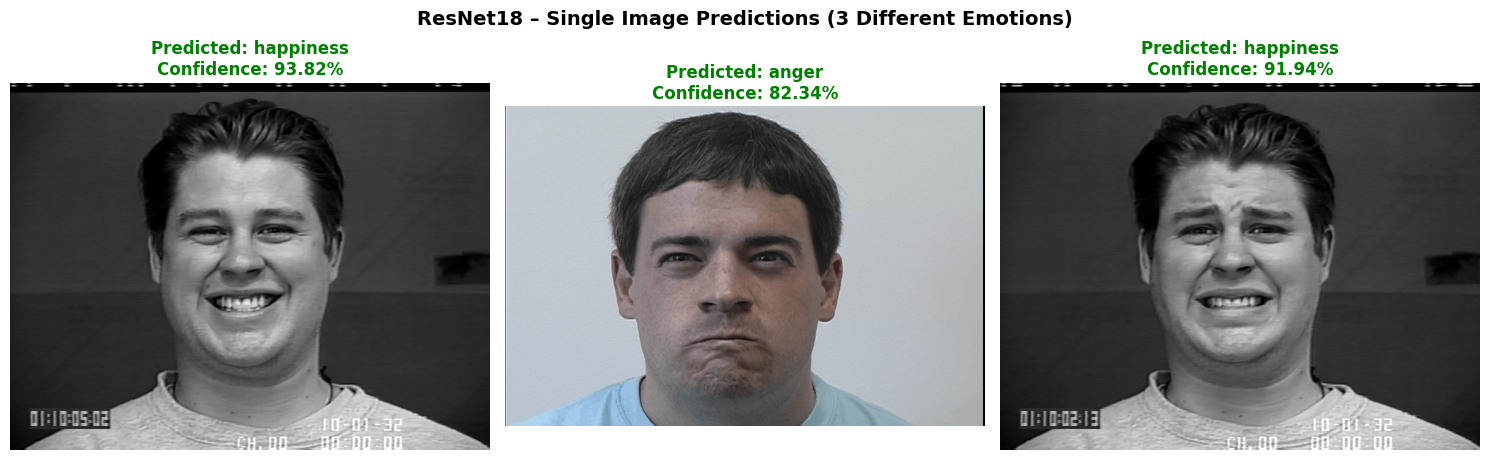

Single image prediction figure saved to Google Drive.


In [ ]:
# Run single‑image emotion predictions using the trained ResNet18 model.
# Each image is preprocessed the same way as during training.
TEST_IMAGES = [
    '/content/drive/MyDrive/CK+/test/happiness/S132_006_00000023.png',
    '/content/drive/MyDrive/CK+/test/anger/S506_001_00000040 (1).png',
    '/content/drive/MyDrive/CK+/test/fear/S132_003_00000023 (1).png',
]

EMOTION_LABELS = train_dataset_ck.classes

def predict_emotion_resnet(image_path, model, device):
    """
    Loads a single image, preprocesses it the same way as training,
    and returns the predicted emotion label and confidence score.
    """

    img = cv2.imread(image_path) # load image
    if img is None:
        return None, None, None

    original_img = img.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1,
                                           minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print(f"  No face detected in {image_path} – using full image")
        face_img = cv2.resize(img, (224, 224))
    else:
        x, y, w, h = faces[0]
        face_img = img[y:y+h, x:x+w]
        face_img = cv2.resize(face_img, (224, 224))

    from PIL import Image
    pil_img = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
    tensor_img = transform(pil_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor_img)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    predicted_label = EMOTION_LABELS[predicted_class.item()]
    confidence_score = confidence.item()

    return original_img, predicted_label, confidence_score

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ResNet18 – Single Image Predictions (3 Different Emotions)',
             fontsize=14, fontweight='bold')

# Loop through the selected test images and display predicted emotion + confidence.
for i, (img_path, ax) in enumerate(zip(TEST_IMAGES, axes)):
    original, label, conf = predict_emotion_resnet(img_path, resnet18, device)

    if original is not None:
        rgb_img = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        ax.imshow(rgb_img)
        ax.set_title(f'Predicted: {label}\nConfidence: {conf:.2%}',
                     fontsize=12, fontweight='bold', color='green')
    else:
        ax.text(0.5, 0.5, f'Image not found:\n{img_path}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='red')
        ax.set_title(f'Sample {i+1}')

    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/single_image_predictions.png', dpi=150)
plt.show()
print("Single image prediction figure saved to Google Drive.")

In [ ]:
print("  Files saved to Google Drive:")
print("  ├── custom_cnn_ck.h5                  (Custom CNN – CK+)")
print("  ├── custom_cnn_jaffe.h5               (Custom CNN – JAFFE)")
print("  ├── resnet18_ck.pth                   (ResNet18 – CK+)")
print("  ├── resnet18_jaffe.pth                (ResNet18 – JAFFE)")
print("  ├── cnn_ck_accuracy_loss.png          (Training plot)")
print("  ├── cnn_jaffe_accuracy_loss.png       (Training plot)")
print("  ├── cnn_ck_confusion_matrix.png       (Confusion matrix)")
print("  ├── cnn_jaffe_confusion_matrix.png    (Confusion matrix)")
print("  ├── resnet18_ck_accuracy_loss.png     (Training plot)")
print("  ├── resnet18_jaffe_accuracy_loss.png  (Training plot)")
print("  ├── resnet18_ck_confusion_matrix.png  (Confusion matrix)")
print("  ├── resnet18_jaffe_confusion_matrix.png (Confusion matrix)")
print("  └── single_image_predictions.png     (Required figure for report)")

  Files saved to Google Drive:
  ├── custom_cnn_ck.h5                  (Custom CNN – CK+)
  ├── custom_cnn_jaffe.h5               (Custom CNN – JAFFE)
  ├── resnet18_ck.pth                   (ResNet18 – CK+)
  ├── resnet18_jaffe.pth                (ResNet18 – JAFFE)
  ├── cnn_ck_accuracy_loss.png          (Training plot)
  ├── cnn_jaffe_accuracy_loss.png       (Training plot)
  ├── cnn_ck_confusion_matrix.png       (Confusion matrix)
  ├── cnn_jaffe_confusion_matrix.png    (Confusion matrix)
  ├── resnet18_ck_accuracy_loss.png     (Training plot)
  ├── resnet18_jaffe_accuracy_loss.png  (Training plot)
  ├── resnet18_ck_confusion_matrix.png  (Confusion matrix)
  ├── resnet18_jaffe_confusion_matrix.png (Confusion matrix)
  └── single_image_predictions.png     (Required figure for report)
